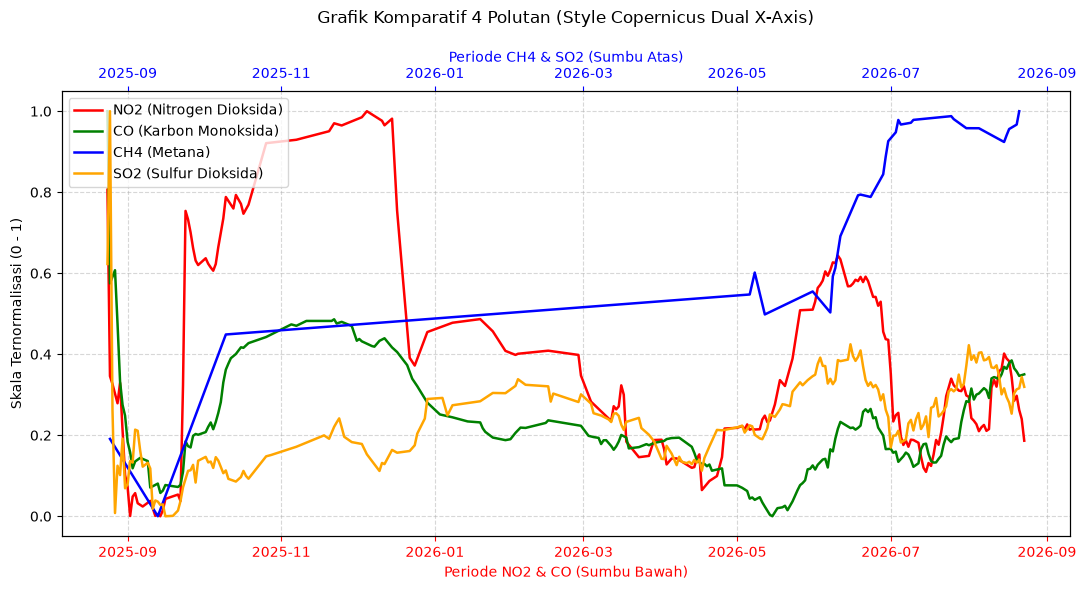

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Data 4 Polutan
df_no2 = pd.read_csv("../data/csv/kabupaten/NO2_gresik_timeseries.csv").dropna(subset=['NO2'])
df_co  = pd.read_csv("../data/csv/kabupaten/CO_gresik_timeseries.csv").dropna(subset=['CO'])
df_ch4 = pd.read_csv("../data/csv/kabupaten/CH4_gresik_timeseries.csv").dropna(subset=['CH4'])
df_so2 = pd.read_csv("../data/csv/kabupaten/SO2_gresik_timeseries.csv").dropna(subset=['SO2'])

df_no2['date'] = pd.to_datetime(df_no2['date'])
df_co['date']  = pd.to_datetime(df_co['date'])
df_ch4['date'] = pd.to_datetime(df_ch4['date'])
df_so2['date'] = pd.to_datetime(df_so2['date'])

# 2. Smooth data dengan 30-day moving average (seperti .rolling(t=30).mean() di Copernicus)
df_no2['NO2_smooth'] = df_no2['NO2'].rolling(window=30, min_periods=1).mean()
df_co['CO_smooth']   = df_co['CO'].rolling(window=30, min_periods=1).mean()
df_ch4['CH4_smooth'] = df_ch4['CH4'].rolling(window=30, min_periods=1).mean()
df_so2['SO2_smooth'] = df_so2['SO2'].rolling(window=30, min_periods=1).mean()

# 3. Normalisasi Min-Max (0 - 1) agar ke-4 polutan dengan skala berbeda dapat dibandingkan dalam 1 grafik
for df, col in [(df_no2, 'NO2_smooth'), (df_co, 'CO_smooth'), (df_ch4, 'CH4_smooth'), (df_so2, 'SO2_smooth')]:
    df[col + '_norm'] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

# 4. Membuat Figure dengan Dual X-Axis (Gaya Copernicus)
fig, ax1 = plt.subplots(figsize=(11, 6), dpi=100)

# Sumbu X Bawah (ax1): NO2 (Merah) & CO (Hijau)
(line1,) = ax1.plot(df_no2['date'], df_no2['NO2_smooth_norm'], color="r", label="NO2 (Nitrogen Dioksida)", linewidth=1.8)
(line2,) = ax1.plot(df_co['date'],  df_co['CO_smooth_norm'],   color="g", label="CO (Karbon Monoksida)", linewidth=1.8)

ax1.set_xlabel("Periode NO2 & CO (Sumbu Bawah)", color='r', fontsize=10)
ax1.set_ylabel("Skala Ternormalisasi (0 - 1)")
ax1.xaxis.label.set_color("r")
ax1.tick_params(axis="x", colors="r")
ax1.grid(True, linestyle='--', alpha=0.5)

# Sumbu X Atas (ax2): CH4 (Biru) & SO2 (Oranye)
ax2 = ax1.twiny()
(line3,) = ax2.plot(df_ch4['date'], df_ch4['CH4_smooth_norm'], color="b", label="CH4 (Metana)", linewidth=1.8)
(line4,) = ax2.plot(df_so2['date'], df_so2['SO2_smooth_norm'], color="orange", label="SO2 (Sulfur Dioksida)", linewidth=1.8)

ax2.set_xlabel("Periode CH4 & SO2 (Sumbu Atas)", color='b', fontsize=10)
ax2.xaxis.label.set_color("b")
ax2.tick_params(axis="x", colors="b")

# 5. Gabungkan Legend dari kedua sumbu (Persis seperti sintaksis Copernicus)
lines = [line1, line2, line3, line4]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Grafik Komparatif 4 Polutan (Style Copernicus Dual X-Axis)", pad=20)
plt.tight_layout()
plt.show()